# EfficientNet-B3 Baseline / No Fourier — teljes test evaluation

Ez a notebook a mentett baseline EfficientNet-B3 modellt értékeli ki a testhalmazon.

Checkpoint:
`/content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/best_efficientnetb3_baseline.pth`

Tartalmazza:
- checkpoint betöltés,
- automatikus class folder felismerés,
- classification report,
- confusion matrix,
- normalized confusion matrix,
- per-image predictions,
- misclassified samples CSV.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import shutil
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision import models, transforms
from torchvision.transforms import InterpolationMode

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Torch:", torch.__version__)

Device: cpu
Torch: 2.10.0+cpu


In [3]:
# =========================
# BEÁLLÍTÁSOK
# =========================

EFFICIENTNET_CKPT = "/content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/best_efficientnetb3_baseline.pth"

TEST_DIR = "/content/drive/MyDrive/Brain MRI/brisc2025/classification_task/test"

OUT_DIR = "/content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation"
os.makedirs(OUT_DIR, exist_ok=True)

# EfficientNet-B3 esetén jellemzően 300x300.
IMG_SIZE = 300
BATCH_SIZE = 8
NUM_WORKERS = 2

CLASS_NAMES = ["glioma", "meningioma", "no_tumor", "pituitary"]
label_map = {c: i for i, c in enumerate(CLASS_NAMES)}
label_map_inv = {i: c for c, i in label_map.items()}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

print("Checkpoint exists:", os.path.exists(EFFICIENTNET_CKPT))
print("Test exists:", os.path.exists(TEST_DIR))
print("Output:", OUT_DIR)

Checkpoint exists: True
Test exists: True
Output: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation


In [4]:
# =========================
# ÚTVONALAK ELLENŐRZÉSE
# =========================

if not os.path.exists(EFFICIENTNET_CKPT):
    raise FileNotFoundError(f"Checkpoint nem található: {EFFICIENTNET_CKPT}")

if not os.path.exists(TEST_DIR):
    raise FileNotFoundError(f"Test mappa nem található: {TEST_DIR}")

print("\nTest mappa tartalma:")
for item in sorted(os.listdir(TEST_DIR)):
    p = os.path.join(TEST_DIR, item)
    if os.path.isdir(p):
        n = len([
            f for f in os.listdir(p)
            if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff"))
        ])
        print(f"{item:25s} -> {n} kép")


Test mappa tartalma:
glioma                    -> 254 kép
meningioma                -> 306 kép
no_tumor                  -> 140 kép
pituitary                 -> 300 kép


In [5]:
# =========================
# TEST DATAFRAME
# =========================

def normalize_folder_name(name):
    s = name.lower().strip().replace("-", "_").replace(" ", "_")
    if "glioma" in s:
        return "glioma"
    if "meningioma" in s:
        return "meningioma"
    if "pituitary" in s:
        return "pituitary"
    if s in ["no_tumor", "notumor", "no_tumour", "notumour", "normal", "healthy"]:
        return "no_tumor"
    if "no" in s and ("tumor" in s or "tumour" in s):
        return "no_tumor"
    return s

valid_exts = (".png", ".jpg", ".jpeg", ".bmp", ".webp", ".tif", ".tiff")

rows = []

for folder in sorted(os.listdir(TEST_DIR)):
    folder_path = os.path.join(TEST_DIR, folder)
    if not os.path.isdir(folder_path):
        continue

    label = normalize_folder_name(folder)

    if label not in label_map:
        print("Kihagyva:", folder, "->", label)
        continue

    for fname in sorted(os.listdir(folder_path)):
        if fname.lower().endswith(valid_exts):
            rows.append({
                "image_path": os.path.join(folder_path, fname),
                "folder_label": folder,
                "label": label,
                "label_idx": label_map[label]
            })

df_test = pd.DataFrame(rows)

if len(df_test) == 0:
    raise RuntimeError("Nem találtam képeket a test mappában.")

print("Összes test kép:", len(df_test))
display(df_test["label"].value_counts().reindex(CLASS_NAMES).fillna(0).astype(int).to_frame("count"))

file_list_path = os.path.join(OUT_DIR, "test_file_list.csv")
df_test.to_csv(file_list_path, index=False)
print("Mentve:", file_list_path)

display(df_test.head())

Összes test kép: 1000


,count
label,
glioma,254
meningioma,306
no_tumor,140
pituitary,300


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/test_file_list.csv


,image_path,folder_label,label,label_idx
0,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
1,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
2,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
3,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0
4,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,glioma,glioma,0


In [6]:
# =========================
# DATASET ÉS DATALOADER
# =========================

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

class BrainTumorDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label_idx"])

        if self.transform:
            image = self.transform(image)

        return image, label, row["image_path"]

test_dataset = BrainTumorDataset(df_test, transform=test_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available()
)

print("Dataset:", len(test_dataset))
print("Batches:", len(test_loader))

Dataset: 1000
Batches: 125


In [7]:
# =========================
# MODELL: EfficientNet-B3 baseline no Fourier
# =========================

model = models.efficientnet_b3(weights=None)

# torchvision EfficientNet classifier: Sequential(Dropout, Linear)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, len(CLASS_NAMES))

model = model.to(device)

print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=4, bias=True)
)


In [8]:
# =========================
# CHECKPOINT BETÖLTÉSE
# Drive transport hiba ellen: először local /content alá másoljuk
# =========================

LOCAL_CKPT = "/content/best_efficientnetb3_baseline.pth"
shutil.copy2(EFFICIENTNET_CKPT, LOCAL_CKPT)

try:
    ckpt = torch.load(LOCAL_CKPT, map_location=device, weights_only=True)
except TypeError:
    ckpt = torch.load(LOCAL_CKPT, map_location=device)
except Exception:
    ckpt = torch.load(LOCAL_CKPT, map_location=device)

if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
    state = ckpt["model_state_dict"]
elif isinstance(ckpt, dict) and "state_dict" in ckpt:
    state = ckpt["state_dict"]
else:
    state = ckpt

state = {k.replace("module.", ""): v for k, v in state.items()}

missing, unexpected = model.load_state_dict(state, strict=False)

print("Checkpoint loaded from:", LOCAL_CKPT)

if missing:
    print("\nHiányzó kulcsok:")
    for k in missing[:50]:
        print(" ", k)
    if len(missing) > 50:
        print(" ...")

if unexpected:
    print("\nVáratlan kulcsok:")
    for k in unexpected[:50]:
        print(" ", k)
    if len(unexpected) > 50:
        print(" ...")

if len(missing) == 0 and len(unexpected) == 0:
    print("Sikeres betöltés: nincs missing/unexpected kulcs.")

model.eval()

Checkpoint loaded from: /content/best_efficientnetb3_baseline.pth
Sikeres betöltés: nincs missing/unexpected kulcs.


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActiv

In [9]:
# =========================
# TEST KIÉRTÉKELÉS
# =========================

y_true = []
y_pred = []
y_prob = []
paths = []

use_amp = torch.cuda.is_available()

with torch.no_grad():
    for images, labels, image_paths in tqdm(test_loader, desc="Testing"):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.amp.autocast("cuda", enabled=use_amp):
            outputs = model(images)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())
        paths.extend(list(image_paths))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("Predikciók elkészültek.")
print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)
print("y_prob:", y_prob.shape)

Testing:   0%|          | 0/125 [00:00<?, ?it/s]

Predikciók elkészültek.
y_true: (1000,)
y_pred: (1000,)
y_prob: (1000, 4)


In [10]:
# =========================
# SUMMARY METRICS
# =========================

acc = accuracy_score(y_true, y_pred)

summary_df = pd.DataFrame([{
    "Model": "EfficientNet-B3 Baseline",
    "Test Accuracy": acc,
    "Macro Precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro Recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    "Macro F1-score": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "Weighted Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
    "Weighted F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "Number of test images": len(y_true)
}])

display(summary_df)

summary_path = os.path.join(OUT_DIR, "test_summary_metrics.csv")
summary_df.to_csv(summary_path, index=False)
print("Mentve:", summary_path)

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Weighted Precision,Weighted Recall,Weighted F1-score,Number of test images
0,EfficientNet-B3 Baseline,0.986,0.987202,0.987191,0.987144,0.986139,0.986,0.986012,1000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/test_summary_metrics.csv


In [11]:
# =========================
# CLASSIFICATION REPORT
# =========================

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        labels=list(range(len(CLASS_NAMES))),
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0
    )
).transpose()

display(report_df)

report_path = os.path.join(OUT_DIR, "classification_report.csv")
report_df.to_csv(report_path)
print("Mentve:", report_path)

,precision,recall,f1-score,support
glioma,0.987952,0.968504,0.978131,254.000
meningioma,0.967949,0.986928,0.977346,306.000
no_tumor,0.992908,1.000000,0.996441,140.000
pituitary,1.000000,0.993333,0.996656,300.000
accuracy,0.986000,0.986000,0.986000,0.986
macro avg,0.987202,0.987191,0.987144,1000.000
weighted avg,0.986139,0.986000,0.986012,1000.000


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/classification_report.csv


In [12]:
# =========================
# PAPER-READY METRIKA TÁBLÁZAT
# =========================

prec, rec, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=list(range(len(CLASS_NAMES))),
    zero_division=0
)

rows = []

for i, cls in enumerate(CLASS_NAMES):
    rows.append({
        "Model": "EfficientNet-B3 Baseline",
        "Class": cls,
        "Precision": round(float(prec[i]), 4),
        "Recall": round(float(rec[i]), 4),
        "F1-Score": round(float(f1[i]), 4),
        "Support": int(support[i]),
        "Accuracy": ""
    })

rows.append({
    "Model": "",
    "Class": "Macro Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="macro", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": ""
})

rows.append({
    "Model": "",
    "Class": "Weighted Avg",
    "Precision": round(float(precision_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Recall": round(float(recall_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "F1-Score": round(float(f1_score(y_true, y_pred, average="weighted", zero_division=0)), 4),
    "Support": int(np.sum(support)),
    "Accuracy": round(float(acc), 4)
})

results_table_df = pd.DataFrame(rows)
display(results_table_df)

results_path = os.path.join(OUT_DIR, "test_results_table.csv")
results_table_df.to_csv(results_path, index=False)
print("Mentve:", results_path)

,Model,Class,Precision,Recall,F1-Score,Support,Accuracy
0,EfficientNet-B3 Baseline,glioma,0.9880,0.9685,0.9781,254,
1,EfficientNet-B3 Baseline,meningioma,0.9679,0.9869,0.9773,306,
2,EfficientNet-B3 Baseline,no_tumor,0.9929,1.0000,0.9964,140,
3,EfficientNet-B3 Baseline,pituitary,1.0000,0.9933,0.9967,300,
4,,Macro Avg,0.9872,0.9872,0.9871,1000,
5,,Weighted Avg,0.9861,0.9860,0.9860,1000,0.986


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/test_results_table.csv


,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,246,8,0,0
True: meningioma,3,302,1,0
True: no_tumor,0,0,140,0
True: pituitary,0,2,0,298


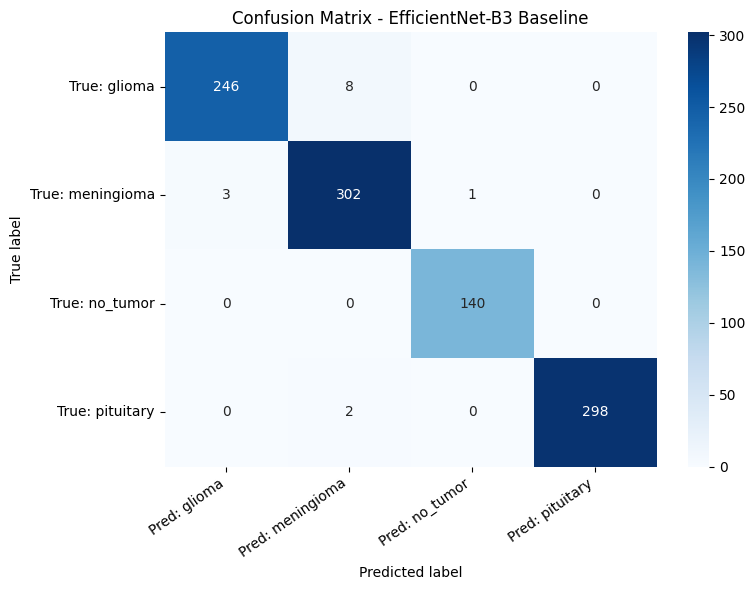

CSV: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/confusion_matrix_counts.csv
PNG: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/confusion_matrix.png


In [13]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))

cm_df = pd.DataFrame(
    cm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_df)

cm_csv = os.path.join(OUT_DIR, "confusion_matrix_counts.csv")
cm_df.to_csv(cm_csv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title("Confusion Matrix - EfficientNet-B3 Baseline")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_png = os.path.join(OUT_DIR, "confusion_matrix.png")
plt.savefig(cm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV:", cm_csv)
print("PNG:", cm_png)

,Pred: glioma,Pred: meningioma,Pred: no_tumor,Pred: pituitary
True: glioma,0.968504,0.031496,0.000000,0.000000
True: meningioma,0.009804,0.986928,0.003268,0.000000
True: no_tumor,0.000000,0.000000,1.000000,0.000000
True: pituitary,0.000000,0.006667,0.000000,0.993333


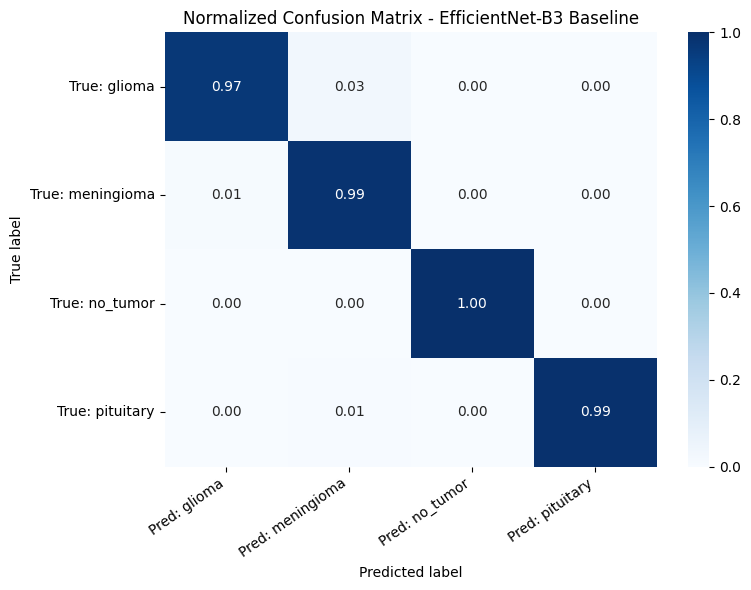

CSV: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/confusion_matrix_normalized.csv
PNG: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/normalized_confusion_matrix.png


In [14]:
# =========================
# NORMALIZED CONFUSION MATRIX
# =========================

row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

cm_norm_df = pd.DataFrame(
    cm_norm,
    index=[f"True: {c}" for c in CLASS_NAMES],
    columns=[f"Pred: {c}" for c in CLASS_NAMES]
)

display(cm_norm_df)

cm_norm_csv = os.path.join(OUT_DIR, "confusion_matrix_normalized.csv")
cm_norm_df.to_csv(cm_norm_csv)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2f", cmap="Blues", cbar=True, vmin=0, vmax=1)
plt.title("Normalized Confusion Matrix - EfficientNet-B3 Baseline")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

cm_norm_png = os.path.join(OUT_DIR, "normalized_confusion_matrix.png")
plt.savefig(cm_norm_png, dpi=300, bbox_inches="tight")
plt.show()

print("CSV:", cm_norm_csv)
print("PNG:", cm_norm_png)

In [15]:
# =========================
# PER-IMAGE PREDICTIONS + MISCLASSIFIED
# =========================

pred_rows = []

for i in range(len(y_true)):
    row = {
        "image_path": paths[i],
        "true_idx": int(y_true[i]),
        "pred_idx": int(y_pred[i]),
        "true_label": label_map_inv[int(y_true[i])],
        "predicted_label": label_map_inv[int(y_pred[i])],
        "correct": bool(y_true[i] == y_pred[i]),
        "confidence": float(np.max(y_prob[i]))
    }

    for j, cname in enumerate(CLASS_NAMES):
        row[f"prob_{cname}"] = float(y_prob[i][j])

    pred_rows.append(row)

pred_df = pd.DataFrame(pred_rows)
display(pred_df.head(20))

pred_path = os.path.join(OUT_DIR, "per_image_predictions.csv")
pred_df.to_csv(pred_path, index=False)
print("Mentve:", pred_path)

wrong_df = pred_df[pred_df["correct"] == False].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)

display(wrong_df.head(50))

wrong_path = os.path.join(OUT_DIR, "misclassified.csv")
wrong_df.to_csv(wrong_path, index=False)
print("Mentve:", wrong_path)

,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
0,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.998956,0.998956,0.000027,1.866667e-07,0.001016
1,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.992645,0.992645,0.000010,3.451554e-07,0.007344
2,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999044,0.999044,0.000650,2.479162e-04,0.000058
3,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.613925,0.613925,0.338108,3.181552e-04,0.047648
4,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.808349,0.808349,0.002296,1.360718e-07,0.189354
5,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.998932,0.998932,0.001057,4.397960e-07,0.000011
6,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.998791,0.998791,0.000049,2.558028e-05,0.001134
7,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999109,0.999109,0.000054,6.711117e-04,0.000166
8,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.999899,0.999899,0.000076,4.723661e-06,0.000021
9,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,0,glioma,glioma,True,0.988445,0.988445,0.000015,3.386605e-06,0.011536


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/per_image_predictions.csv


,image_path,true_idx,pred_idx,true_label,predicted_label,correct,confidence,prob_glioma,prob_meningioma,prob_no_tumor,prob_pituitary
29,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.999451,0.000331,0.999451,1.738761e-07,0.000218
91,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.999451,0.000331,0.999451,1.738761e-07,0.000218
533,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.995328,0.995328,0.004651,8.060292e-08,0.000021
145,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.976461,0.020603,0.976461,5.799414e-05,0.002878
228,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.970039,0.028090,0.970039,1.163606e-03,0.000708
150,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.955682,0.041801,0.955682,1.783004e-04,0.002339
532,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,1,0,meningioma,glioma,False,0.878538,0.878538,0.118800,4.216280e-04,0.002240
721,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,3,1,pituitary,meningioma,False,0.811289,0.001634,0.811289,1.281126e-05,0.187064
825,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,3,1,pituitary,meningioma,False,0.782064,0.000042,0.782064,9.427304e-06,0.217884
233,/content/drive/MyDrive/Brain MRI/brisc2025/cla...,0,1,glioma,meningioma,False,0.703996,0.295279,0.703996,2.375840e-06,0.000723


Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/misclassified.csv


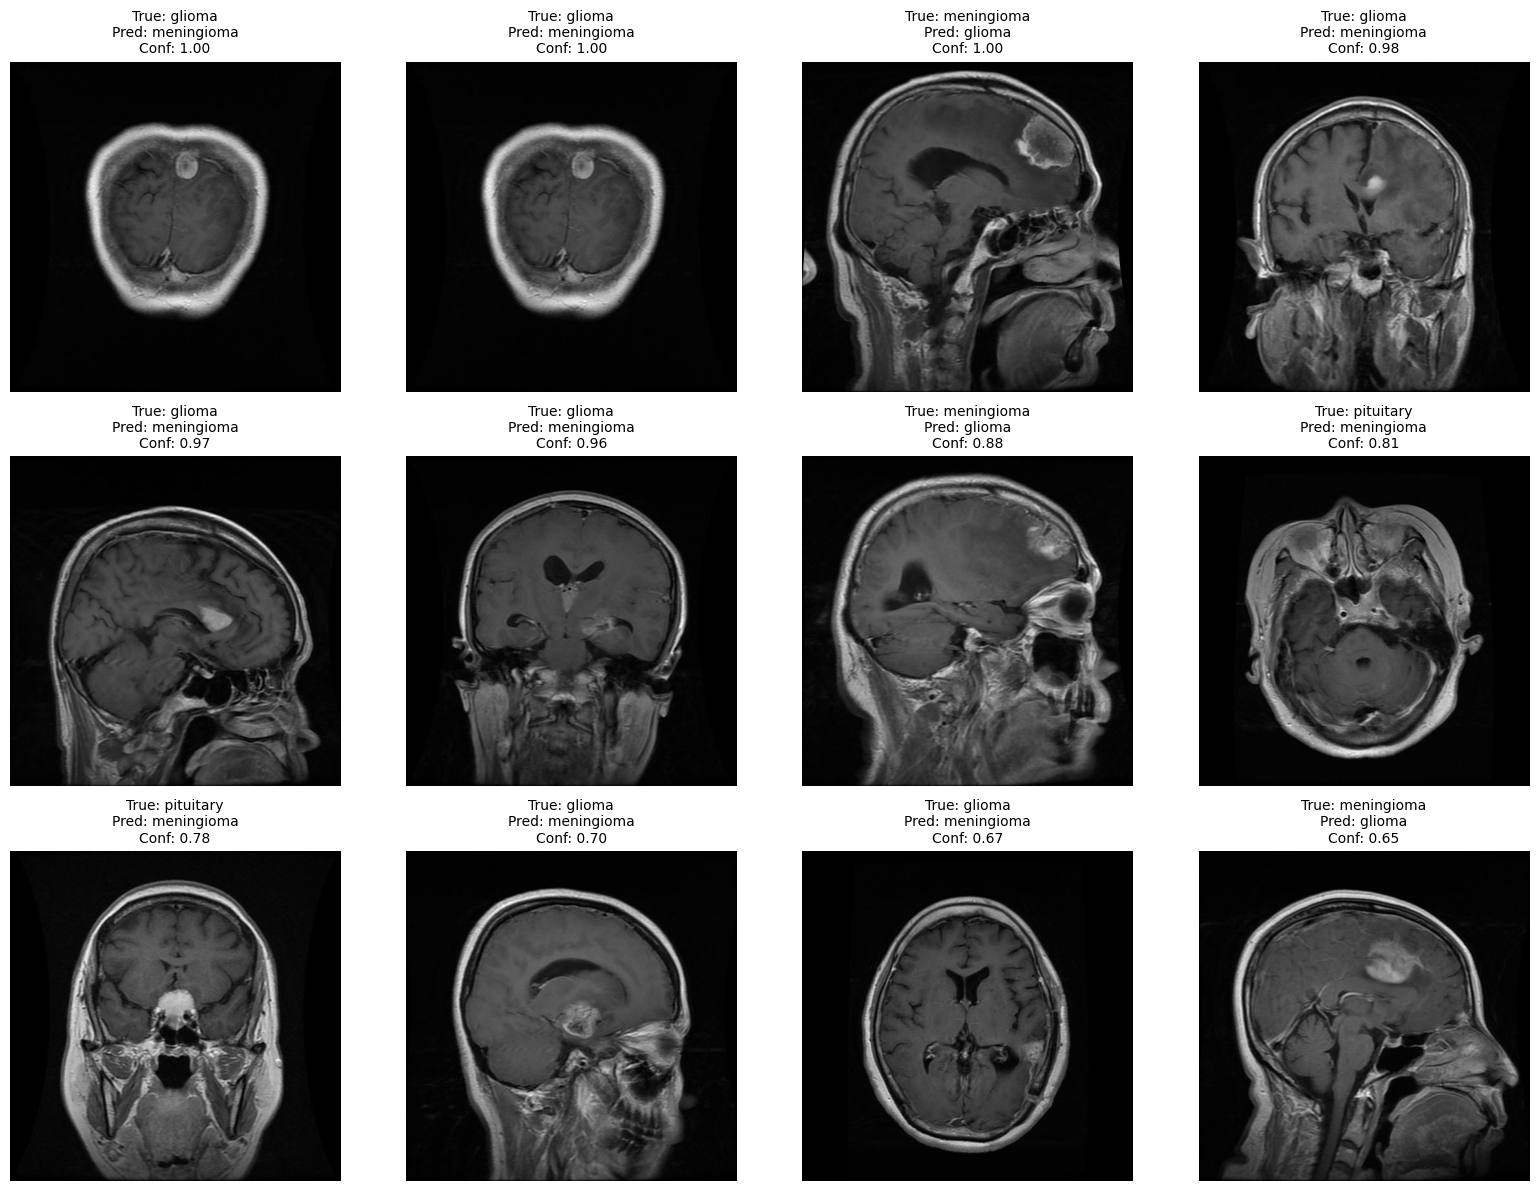

Mentve: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation/misclassified_examples.png


In [16]:
# =========================
# MISCLASSIFIED EXAMPLES
# =========================

def show_misclassified_examples(wrong_df, max_images=12):
    if len(wrong_df) == 0:
        print("Nincs hibás klasszifikáció.")
        return

    sample_df = wrong_df.head(max_images)
    n = len(sample_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = Image.open(row["image_path"]).convert("RGB")
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row['true_label']}\nPred: {row['predicted_label']}\nConf: {row['confidence']:.2f}",
            fontsize=10
        )

    plt.tight_layout()
    out_path = os.path.join(OUT_DIR, "misclassified_examples.png")
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Mentve:", out_path)

show_misclassified_examples(wrong_df)

In [17]:
print("Kész.")
print("Eredmények:", OUT_DIR)
print("\nFájlok:")
for f in sorted(os.listdir(OUT_DIR)):
    print("-", f)

Kész.
Eredmények: /content/drive/MyDrive/Brain MRI/FNO_clas/no fourier/efficientnetb3_test_evaluation

Fájlok:
- classification_report.csv
- confusion_matrix.png
- confusion_matrix_counts.csv
- confusion_matrix_normalized.csv
- misclassified.csv
- misclassified_examples.png
- normalized_confusion_matrix.png
- per_image_predictions.csv
- test_file_list.csv
- test_results_table.csv
- test_summary_metrics.csv
